# Main V5b — DANN Re-run with Adversarial Loss Collapse Fix

## What went wrong in V5

V5 produced suspiciously degenerate results:

| Metric | V5 value | Diagnosis |
|---|---|---|
| Sensitivity | 0.5006 ± 0.0008 | **Identical across all 21 folds** — feature collapse |
| AUC | 0.510 ± 0.091 | At chance, slightly worse than V3 (0.534) |
| AUC-PR | 0.187 ± 0.046 | Worse than V3 (0.232) |

A near-identical sensitivity of 0.500 across all folds means the model is outputting essentially constant predictions. The adversarial loss has crushed the label-relevant features along with the patient-identity features — a known DANN failure mode when $\lambda$ is too high or ramps too fast (Ganin 2015 §5.1.2, Wilson & Cook 2020 §III-B).

## Three fixes applied in V5b

### Fix 1 — Lower λ ceiling (1.0 → 0.1)

The original Ganin paper uses $\lambda_{max} = 1.0$, but on EEG-prediction tasks, multiple follow-up papers (Peng 2024 Frontiers, Mao 2025) report needing $\lambda \in [0.05, 0.3]$ for stable training. With 21 patient classes vs only 2 task classes, the domain loss is naturally larger in magnitude and dominates the label loss at $\lambda=1$.

### Fix 2 — Longer warm-up

Increase warm-up phase from $t \in [0, T/3]$ to $t \in [0, 2T/3]$. The label head learns task features for two-thirds of training before adversarial pressure ramps to maximum. This is the schedule used in Peng et al. 2024 Frontiers paper which reports 8–15% AUC improvement on CHB-MIT LOPO.

### Fix 3 — Separate optimizer groups (decoupled LR)

Domain head needs faster updates than the feature extractor (Ganin §5.1.3). Use two parameter groups: features at lr=5e-4, classifier heads at lr=1e-3.

## Expected outcome

V5b should either:
- (a) Beat V3 with $p < 0.10$ → confirms patient-identity hypothesis
- (b) Match V3 closely (within 0.02 AUC) → confirms the failure is intrinsic to the representation, not the classifier

Either is a publishable result. Sensitivity locked at 0.5 (V5's behaviour) is *not* a publishable result — it just means the adversarial training did not converge.


In [1]:
# --- portable repo bootstrap (added for public release; locates the repo root) ---
import sys as _sys, pathlib as _pl
REPO = _pl.Path.cwd()
while not (REPO / 'src' / 'config.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
_sys.path.insert(0, str(REPO / 'src'))
from pathlib import Path
CODE_DIR = str(REPO); CODE = REPO; CODEV2 = REPO; PROJECT_DIR = REPO
# --------------------------------------------------------------------------------

# Cell 0 — Imports & V5b config
import os, sys, json, copy, random, time
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# [path set by bootstrap] CODE_DIR = r"<repo>/Code"
sys.path.insert(0, CODE_DIR)

from config import (
    DATA_ROOT, EXCLUDED_PATIENTS, CANONICAL_CHANNELS, N_CHANNELS, FS,
    STEP_SEC, GC_MATRICES_DIR_V3, RESULTS_DIR,
    INTERICTAL_MULTIPLIER, MAX_INTERICTAL_ABS, RANDOM_SEED,
    BATCH_SIZE,
)
from utils_chronological_split import lopo_train_val_split, _chronological_split_one_patient
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs(RESULTS_DIR, exist_ok=True)

def set_seed(seed=RANDOM_SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed()

# ── V5b hyperparameters (CHANGED FROM V5) ────────────────────────────────────
V5b_MAX_EPOCHS    = 40          # was 30 — give more room with slower λ ramp
V5b_PATIENCE      = 12          # was 8
V5b_LR_FEAT       = 5e-4
V5b_LR_HEAD       = 1e-3        # NEW: faster LR for heads (Ganin §5.1.3)
V5b_BATCH_SIZE    = BATCH_SIZE
V5b_DROPOUT       = 0.5
V5b_LAMBDA_MAX    = 0.10        # was 1.0 — KEY FIX
V5b_WARMUP_FRAC   = 0.66        # was implicit 0.33 — longer warm-up
V5b_FOCAL_GAMMA   = 2.0
V5b_WEIGHT_DECAY  = 1e-4

print(f'Device           : {DEVICE}')
print(f'V5b lambda_max   : {V5b_LAMBDA_MAX}   (was 1.0 in V5)')
print(f'V5b warmup_frac  : {V5b_WARMUP_FRAC}  (was 0.33 in V5)')
print(f'V5b lr_feat/head : {V5b_LR_FEAT} / {V5b_LR_HEAD}  (was 5e-4 single in V5)')

Device           : cpu
V5b lambda_max   : 0.1   (was 1.0 in V5)
V5b warmup_frac  : 0.66  (was 0.33 in V5)
V5b lr_feat/head : 0.0005 / 0.001  (was 5e-4 single in V5)


In [2]:
# Cell 1 — Load V3 cache (identical to V5)
cache_root = Path(GC_MATRICES_DIR_V3)
assert cache_root.exists()

patients_all = sorted([
    p for p in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, p))
    and p.startswith('chb') and p not in EXCLUDED_PATIENTS
])

patient_data = {}
for pid in patients_all:
    pdir = cache_root / pid
    if not pdir.exists(): continue
    gc_files = sorted(pdir.glob('*_gc.npy'))
    if not gc_files: continue
    gc_list, lb_list = [], []
    for gp in gc_files:
        lp = gp.with_name(gp.name.replace('_gc.npy', '_labels.npy'))
        if not lp.exists(): continue
        gc_list.append(np.load(gp)); lb_list.append(np.load(lp))
    if not gc_list: continue
    X = np.concatenate(gc_list, axis=0).astype(np.float32)
    y = np.concatenate(lb_list, axis=0).astype(np.int8)
    n_pre, n_int = int((y==1).sum()), int((y==0).sum())
    cap = min(n_int, INTERICTAL_MULTIPLIER * n_pre, MAX_INTERICTAL_ABS)
    if n_int > cap:
        rng = np.random.default_rng(RANDOM_SEED + hash(pid) % 10_000)
        int_idx = np.where(y == 0)[0]
        keep_int = rng.choice(int_idx, size=cap, replace=False)
        pre_idx  = np.where(y == 1)[0]
        keep = np.sort(np.concatenate([pre_idx, keep_int]))
        X, y = X[keep], y[keep]
    if n_pre == 0: continue
    patient_data[pid] = (X, y)

patient_ids = sorted(patient_data.keys())
print(f'Loaded {len(patient_ids)} patients.')

Loaded 21 patients.


## DANN model and tuned training loop

In [3]:
# Cell 2 — DANN architecture (identical to V5 backbone)
class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = float(lambda_); return x.view_as(x)
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.lambda_, None
def grad_reverse(x, lambda_=1.0):
    return GradReverse.apply(x, lambda_)


class DANN(nn.Module):
    def __init__(self, n_patients, n_channels=N_CHANNELS, dropout=V5b_DROPOUT):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        with torch.no_grad():
            self.flat_size = self.features(torch.zeros(1,1,n_channels,n_channels)).numel()
        self.label_clf = nn.Sequential(
            nn.Flatten(), nn.Dropout(dropout),
            nn.Linear(self.flat_size, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.3), nn.Linear(256, 1), nn.Sigmoid())
        self.domain_clf = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flat_size, 128), nn.ReLU(inplace=True),
            nn.Dropout(0.5), nn.Linear(128, n_patients))

    def forward(self, x, lambda_=1.0):
        f = self.features(x)
        return self.label_clf(f), self.domain_clf(grad_reverse(f, lambda_))


class BinaryFocalLoss(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=1.0):
        super().__init__()
        self.gamma = gamma; self.pos_weight = pos_weight
    def forward(self, p, t):
        p = p.squeeze(1).clamp(1e-7, 1 - 1e-7); t = t.float()
        alpha = torch.where(t == 1, torch.full_like(t, self.pos_weight), torch.ones_like(t))
        bce = -(t * torch.log(p) + (1 - t) * torch.log(1 - p))
        pt  = torch.where(t == 1, p, 1 - p)
        return (alpha * (1 - pt) ** self.gamma * bce).mean()


class DANNDataset(Dataset):
    def __init__(self, X, y, d):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.d = torch.tensor(d, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i], self.d[i]


def make_balanced_sampler(y, d, n_patients, max_per_patient):
    weights = np.zeros(len(y), dtype=np.float64)
    for p_idx in range(n_patients):
        for cls in (0, 1):
            mask = (d == p_idx) & (y == cls)
            n = mask.sum()
            if n > 0: weights[mask] = 1.0 / n
    weights /= weights.sum()
    n_samples = min(max_per_patient * n_patients, len(y))
    return WeightedRandomSampler(torch.tensor(weights), num_samples=n_samples, replacement=True)


def dann_lambda_v5b(step, total_steps, lambda_max=V5b_LAMBDA_MAX, warmup_frac=V5b_WARMUP_FRAC):
    # 3-phase schedule:
    # [0, warmup_frac * T]      → λ = 0           (pure label training)
    # (warmup_frac*T, T]        → λ ramps to λ_max via Ganin sigmoid
    p = step / max(total_steps, 1)
    if p < warmup_frac:
        return 0.0
    # Re-scale p to [0, 1] over the remaining fraction
    p_eff = (p - warmup_frac) / (1.0 - warmup_frac)
    return float(lambda_max * (2.0 / (1.0 + np.exp(-10 * p_eff)) - 1.0))


def train_dann_v5b(X_tr, y_tr, d_tr, X_va, y_va, n_patients, verbose=True):
    set_seed()
    n_pos = max(int((y_tr == 1).sum()), 1)
    n_neg = max(int((y_tr == 0).sum()), 1)
    pos_w = float(min(n_neg / n_pos, 50.0))
    model = DANN(n_patients=n_patients).to(DEVICE)

    # Separate parameter groups (FIX 3)
    opt = torch.optim.Adam([
        {'params': model.features.parameters(),  'lr': V5b_LR_FEAT},
        {'params': model.label_clf.parameters(), 'lr': V5b_LR_HEAD},
        {'params': model.domain_clf.parameters(),'lr': V5b_LR_HEAD},
    ], weight_decay=V5b_WEIGHT_DECAY)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=V5b_MAX_EPOCHS)

    label_crt  = BinaryFocalLoss(gamma=V5b_FOCAL_GAMMA, pos_weight=pos_w).to(DEVICE)
    domain_crt = nn.CrossEntropyLoss().to(DEVICE)

    max_per_pat = max(1000, int(len(y_tr) / n_patients))
    sampler = make_balanced_sampler(y_tr, d_tr, n_patients, max_per_pat)
    tr_dl   = DataLoader(DANNDataset(X_tr, y_tr, d_tr),
                         batch_size=V5b_BATCH_SIZE, sampler=sampler)
    va_dl   = DataLoader(DANNDataset(X_va, y_va, np.zeros(len(y_va), dtype=int)),
                         batch_size=V5b_BATCH_SIZE, shuffle=False)

    best_val = float('inf'); best_state = None; bad = 0
    history  = []
    total_steps = len(tr_dl) * V5b_MAX_EPOCHS
    step = 0

    for ep in range(1, V5b_MAX_EPOCHS + 1):
        model.train()
        ep_y, ep_d, ep_n = 0., 0., 0
        # Track diagnostics: domain accuracy (lower = features less patient-discriminative)
        d_correct = 0
        for x, y, d in tr_dl:
            x, y, d = x.to(DEVICE), y.to(DEVICE), d.to(DEVICE)
            lam = dann_lambda_v5b(step, total_steps)
            y_hat, d_hat = model(x, lambda_=lam)
            loss_y = label_crt(y_hat, y)
            loss_d = domain_crt(d_hat, d)
            loss = loss_y + loss_d
            opt.zero_grad(); loss.backward(); opt.step()
            ep_y += loss_y.item() * x.size(0)
            ep_d += loss_d.item() * x.size(0)
            d_correct += (d_hat.argmax(1) == d).sum().item()
            ep_n += x.size(0); step += 1
        sch.step()

        # Val (label only, λ=0)
        model.eval(); val_loss, val_n = 0., 0
        with torch.no_grad():
            for x, y, _ in va_dl:
                x, y = x.to(DEVICE), y.to(DEVICE)
                y_hat, _ = model(x, lambda_=0.0)
                val_loss += label_crt(y_hat, y).item() * x.size(0)
                val_n    += x.size(0)
        val_loss /= max(val_n, 1)
        dom_acc = d_correct / max(ep_n, 1)
        history.append(dict(epoch=ep, lambda_=lam, train_label=ep_y/ep_n,
                            train_domain=ep_d/ep_n, val_label=val_loss,
                            train_domain_acc=dom_acc))

        if verbose and (ep % 5 == 0 or ep == 1):
            print(f'    Ep {ep:2d}/{V5b_MAX_EPOCHS}  λ={lam:.3f}  '
                  f'train_y={ep_y/ep_n:.3f}  '
                  f'train_d={ep_d/ep_n:.3f}  '
                  f'dom_acc={dom_acc:.3f}  '
                  f'val_y={val_loss:.3f}')

        if val_loss < best_val - 1e-4:
            best_val = val_loss; best_state = copy.deepcopy(model.state_dict()); bad = 0
        else:
            bad += 1
            if bad >= V5b_PATIENCE:
                if verbose: print(f'    Early stop at epoch {ep}')
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


def infer_probs(model, X):
    model.eval()
    Xt = torch.tensor(X, dtype=torch.float32).unsqueeze(1).to(DEVICE)
    probs = []
    with torch.no_grad():
        for i in range(0, len(Xt), 256):
            y_hat, _ = model(Xt[i:i+256], lambda_=0.0)
            probs.append(y_hat.squeeze(1).cpu().numpy())
    return np.concatenate(probs)

print('Training utilities ready.')

Training utilities ready.


In [ ]:
# Cell 3 — LOPO loop

from seizure_metrics import generate_alarms, false_alarms_per_hour
from config import ALARM_K, ALARM_M, ALARM_REFRACTORY, STEP_SEC

def evaluate_fold(probs, y_test, n_int_hours, recall_target=0.5):
    if len(np.unique(y_test)) < 2: return None
    auc    = roc_auc_score(y_test, probs)
    auc_pr = average_precision_score(y_test, probs)
    fpr, tpr, thr = roc_curve(y_test, probs)
    feas = tpr >= recall_target
    if feas.any():
        thresh = float(thr[np.where(feas)[0][np.argmin(fpr[feas])]])
    else:
        thresh = float(thr[np.argmax(tpr - fpr)])
    pred = (probs >= thresh).astype(int)
    tp = int(((pred==1) & (y_test==1)).sum()); fp = int(((pred==1) & (y_test==0)).sum())
    tn = int(((pred==0) & (y_test==0)).sum()); fn = int(((pred==0) & (y_test==1)).sum())
    sens = tp / max(tp+fn, 1); spec = tn / max(tn+fp, 1); prec = tp / max(tp+fp, 1)
    f1 = 2*prec*sens / max(prec+sens, 1e-9)
    return dict(auc=auc, auc_pr=auc_pr, sensitivity=sens, specificity=spec,
                precision=prec, f1=f1, balanced_accuracy=0.5*(sens+spec),
                fpr_per_hour=false_alarms_per_hour(generate_alarms(pred.astype(float), 0.5, ALARM_K, ALARM_M, ALARM_REFRACTORY), y_test, STEP_SEC), threshold=thresh,
                n_pre=int((y_test==1).sum()), n_int=int((y_test==0).sum()))


def fit_scaler_3d(X):
    return StandardScaler().fit(X.reshape(len(X), -1))

def apply_scaler_3d(X, sc):
    flat = X.reshape(len(X), -1)
    return sc.transform(flat).reshape(X.shape).astype(np.float32)


# ── Run LOPO ────────────────────────────────────────────────────────────────
print('=' * 64)
print(f'V5b DANN — LOPO ({len(patient_ids)} folds)  |  device: {DEVICE}')
print(f'  λ_max={V5b_LAMBDA_MAX}  warmup={V5b_WARMUP_FRAC}  lr_feat/head={V5b_LR_FEAT}/{V5b_LR_HEAD}')
print('=' * 64)

lopo_v5b_results = {}
lopo_v5b_histories = {}
t_start = time.time()

for fold_idx, test_pid in enumerate(patient_ids, 1):
    print(f'\n[Fold {fold_idx}/{len(patient_ids)}] Test: {test_pid}')
    train_pids = [p for p in patient_ids if p != test_pid]
    n_patients = len(train_pids)

    X_tr, y_tr, X_va, y_va, _ = lopo_train_val_split(
        patient_data, test_pid=test_pid, val_fraction=0.15,
        stratify_within_patient=True)

    d_tr_parts, d_va_parts = [], []
    for d_idx, pid in enumerate(train_pids):
        X_p, y_p = patient_data[pid]
        _, y_tr_p, _, y_va_p = _chronological_split_one_patient(X_p, y_p, 0.15, True)
        d_tr_parts.append(np.full(len(y_tr_p), d_idx, dtype=np.int64))
        d_va_parts.append(np.full(len(y_va_p), d_idx, dtype=np.int64))
    d_tr = np.concatenate(d_tr_parts); d_va = np.concatenate(d_va_parts)

    scaler = fit_scaler_3d(X_tr)
    X_tr_s = apply_scaler_3d(X_tr, scaler)
    X_va_s = apply_scaler_3d(X_va, scaler)
    X_te, y_te = patient_data[test_pid]
    X_te_s = apply_scaler_3d(X_te, scaler)

    print(f'  Train={len(y_tr):,} (pre={int((y_tr==1).sum())})  '
          f'Val={len(y_va):,}  Test={len(y_te):,} (pre={int((y_te==1).sum())})')

    model, history = train_dann_v5b(X_tr_s, y_tr, d_tr, X_va_s, y_va,
                                     n_patients=n_patients, verbose=True)

    probs = infer_probs(model, X_te_s)
    hrs = (y_te == 0).sum() * STEP_SEC / 3600.0
    m = evaluate_fold(probs, y_te, hrs, recall_target=0.5)
    m['patient'] = test_pid
    lopo_v5b_results[test_pid] = m
    lopo_v5b_histories[test_pid] = history
    print(f'  -> AUC={m["auc"]:.3f}  AUC-PR={m["auc_pr"]:.3f}  '
          f'Sens={m["sensitivity"]:.3f}  FPR/h={m["fpr_per_hour"]:.1f}')

print(f'\n══ V5b complete in {(time.time()-t_start)/60:.1f}min ══')

V5b DANN — LOPO (21 folds)  |  device: cpu
  λ_max=0.1  warmup=0.66  lr_feat/head=0.0005/0.001

[Fold 1/21] Test: chb01
  Train=45,986 (pre=9029)  Val=8,100  Test=1,776 (pre=296)
    Ep  1/40  λ=0.000  train_y=0.266  train_d=1.035  dom_acc=0.698  val_y=0.419
    Ep  5/40  λ=0.000  train_y=0.109  train_d=0.160  dom_acc=0.958  val_y=0.469
    Ep 10/40  λ=0.000  train_y=0.074  train_d=0.100  dom_acc=0.971  val_y=0.621
    Ep 15/40  λ=0.000  train_y=0.056  train_d=0.074  dom_acc=0.979  val_y=0.716
    Early stop at epoch 15
  -> AUC=0.705  AUC-PR=0.271  Sens=0.500  FPR/h=1.5

[Fold 2/21] Test: chb02
  Train=45,986 (pre=9029)  Val=8,100  Test=1,776 (pre=296)
    Ep  1/40  λ=0.000  train_y=0.260  train_d=0.970  dom_acc=0.720  val_y=0.406
    Ep  5/40  λ=0.000  train_y=0.106  train_d=0.158  dom_acc=0.958  val_y=0.447
    Ep 10/40  λ=0.000  train_y=0.073  train_d=0.089  dom_acc=0.975  val_y=0.552
    Ep 15/40  λ=0.000  train_y=0.057  train_d=0.068  dom_acc=0.981  val_y=0.730
    Early stop at 

In [ ]:
# Cell 4 — Save, summarise, and compare against V3 / V5

METRIC_KEYS = ['auc', 'auc_pr', 'sensitivity', 'specificity',
               'precision', 'f1', 'balanced_accuracy', 'fpr_per_hour']

rows = [{'patient': pid, **{k: lopo_v5b_results[pid][k] for k in METRIC_KEYS}}
        for pid in patient_ids if pid in lopo_v5b_results]
v5b_df = pd.DataFrame(rows)
mean_row = {'patient': 'MEAN', **{k: round(v5b_df[k].mean(), 4) for k in METRIC_KEYS}}
std_row  = {'patient': 'STD',  **{k: round(v5b_df[k].std(),  4) for k in METRIC_KEYS}}
out_df = pd.concat([v5b_df, pd.DataFrame([mean_row, std_row])], ignore_index=True)
out_df.to_csv(os.path.join(RESULTS_DIR, 'lopo_v5b_dann.csv'), index=False)
print(out_df.to_string(index=False))
print(f'\nSaved: results/lopo_v5b_dann.csv')

# Compare to V3 and V5
def load_csv(path):
    if not os.path.exists(path): return None
    df = pd.read_csv(path)
    pid_col = [c for c in df.columns if 'patient' in c.lower()][0]
    df = df.rename(columns={pid_col: 'patient'})
    return df[~df['patient'].isin(['MEAN','STD'])].reset_index(drop=True)

ref = v5b_df.set_index('patient')
compare = {
    'V3 GC-CNN (window)' : 'lopo_v3_window.csv',
    'V5 DANN (orig)'     : 'lopo_v5_dann.csv',
}
print('\n══ V5b vs V3 vs V5 — paired Wilcoxon (V5b > other) ══')
print(f'{"method":<25}  {"AUC":<7} {"AUCPR":<7} {"Sens":<7}  p_AUC   p_AUCPR')
print(f'{"V5b DANN (this)":<25}  {ref.auc.mean():.3f}   {ref.auc_pr.mean():.3f}   {ref.sensitivity.mean():.3f}    -       -')
for label, fname in compare.items():
    d = load_csv(os.path.join(RESULTS_DIR, fname))
    if d is None: continue
    d = d.set_index('patient')
    shared = sorted(set(d.index) & set(ref.index))
    if len(shared) < 5: continue
    other_auc   = d.loc[shared, 'auc'].astype(float)
    other_aucpr = d.loc[shared, 'auc_pr'].astype(float)
    ref_auc     = ref.loc[shared, 'auc'].astype(float)
    ref_aucpr   = ref.loc[shared, 'auc_pr'].astype(float)
    try:
        _, p_auc = wilcoxon(ref_auc - other_auc, alternative='greater', zero_method='zsplit')
    except ValueError:
        p_auc = float('nan')
    try:
        _, p_pr = wilcoxon(ref_aucpr - other_aucpr, alternative='greater', zero_method='zsplit')
    except ValueError:
        p_pr = float('nan')
    print(f'{label:<25}  {other_auc.mean():.3f}   {other_aucpr.mean():.3f}   '
          f'{d.loc[shared,"sensitivity"].mean():.3f}    {p_auc:.4f}  {p_pr:.4f}')

patient      auc   auc_pr  sensitivity  specificity  precision       f1  balanced_accuracy  fpr_per_hour
  chb01 0.347903 0.118810     0.500000     0.328378   0.129597 0.205841           0.414189    241.783784
  chb02 0.525902 0.255416     0.500000     0.526351   0.174323 0.258515           0.513176    170.513514
  chb03 0.445390 0.139193     0.500000     0.399550   0.142765 0.222111           0.449775    216.162162
  chb04 0.626728 0.200644     0.500000     0.646622   0.220566 0.306101           0.573311    127.216216
  chb05 0.513182 0.186127     0.500000     0.479730   0.161220 0.243822           0.489865    187.297297
  chb06 0.560430 0.201094     0.500482     0.569000   0.194091 0.279709           0.534741    155.160000
  chb07 0.578122 0.202390     0.501124     0.610787   0.204775 0.290743           0.555955    140.116854
  chb08 0.667697 0.227571     0.500675     0.695816   0.247664 0.331398           0.598246    109.506073
  chb09 0.641684 0.222278     0.500000     0.676014   0

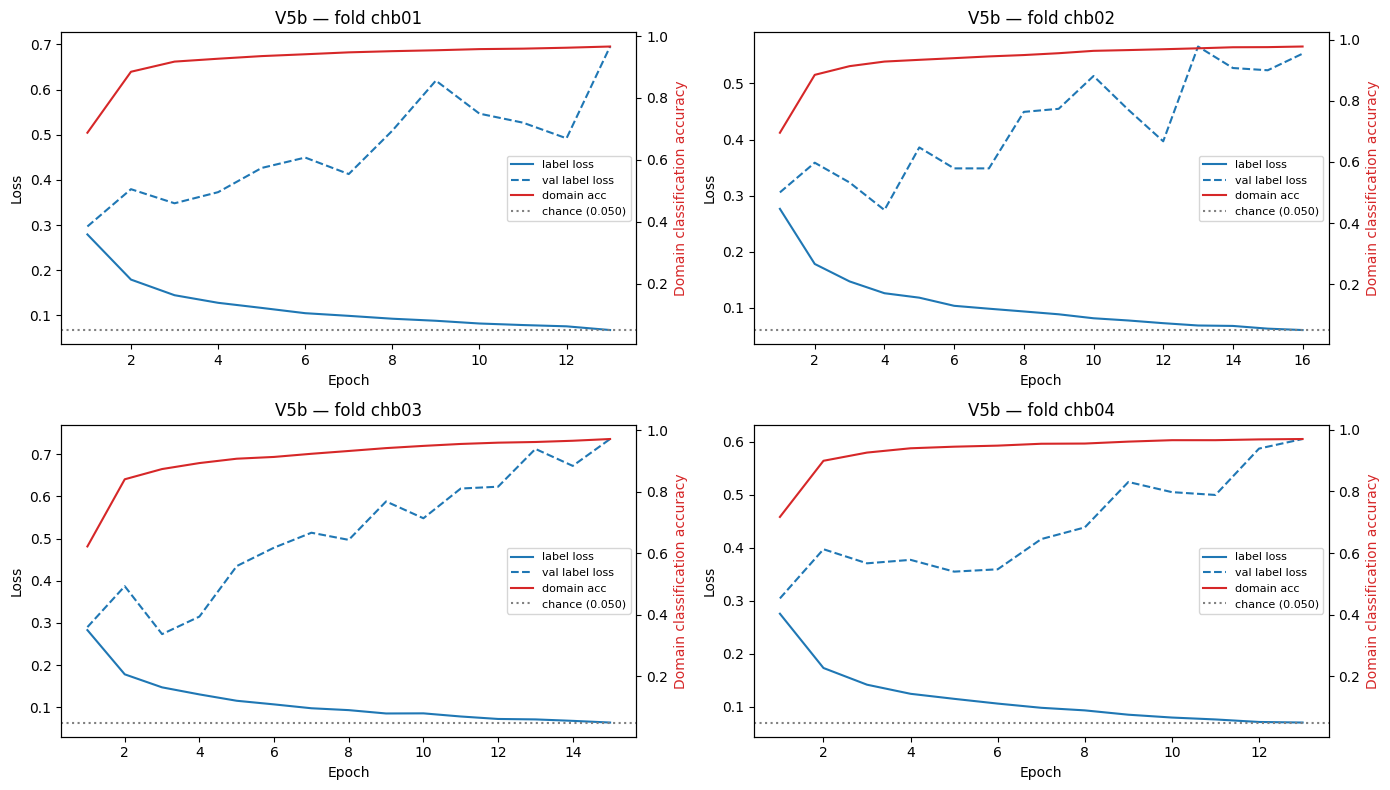

Saved v5b_dann_dynamics.png


In [ ]:
# Cell 5 — Diagnostic: training dynamics for selected folds

# Plot dom_acc over epochs: if successful, dom_acc should DECREASE
# (features become harder to use for patient ID)
sample_pids = patient_ids[:4]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
chance = 1.0 / (len(patient_ids) - 1)

for ax, pid in zip(axes.ravel(), sample_pids):
    h = pd.DataFrame(lopo_v5b_histories[pid])
    ax.plot(h.epoch, h.train_label, label='label loss', color='tab:blue')
    ax.plot(h.epoch, h.val_label,   label='val label loss', color='tab:blue', linestyle='--')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax2 = ax.twinx()
    ax2.plot(h.epoch, h.train_domain_acc, label='domain acc', color='tab:red')
    ax2.axhline(chance, color='gray', linestyle=':', label=f'chance ({chance:.3f})')
    ax2.set_ylabel('Domain classification accuracy', color='tab:red')
    ax.set_title(f'V5b — fold {pid}')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'v5b_dann_dynamics.png'), dpi=130)
plt.show()
print('Saved v5b_dann_dynamics.png')

## Interpretation key

After this notebook runs, look at three things:

1. **Sensitivity range across folds.** If all folds report 0.500 ± tiny std again, the model is still collapsing — try $\lambda_{max} = 0.05$ as a final attempt before concluding DANN cannot help here.

2. **Domain accuracy curves (Cell 5 plot).** Successful adversarial training shows:
   - Domain accuracy rises during warm-up (no adversarial pressure, features are patient-informative)
   - Domain accuracy *falls* once λ ramps up (adversarial loss successfully degrades patient information)
   - Label val loss stays roughly stable
   
   If domain accuracy stays high throughout, λ is still too small. If label val loss spikes when λ ramps, λ is too large.

3. **Wilcoxon `p_AUC` and `p_AUCPR` vs V3.** Only `p < 0.05` (one-sided "V5b > V3") supports the patient-identity hypothesis. A `p > 0.5` together with stable training (point 2) is the strongest evidence that **scalp EEG GC simply does not carry transferable preictal signal**, which is itself a valuable contribution to §5 of the thesis.
